In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [17]:
# Remove warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

In [18]:
# Create dataframe from the provided data

data = {
    'Country' : ['USA', 'Canada', 'France', 'UK', 'Germany', 'Australia'],
    'Latitude' : [44.97, 62.40, 46.75, 54.01, 51.15, -25.45],
    'Longitude' : [-103.77, -96.80, 2.40, -2.53, 10.40, 133.11],
    'Language' : ['English', 'English', 'French', 'English', 'German', 'English']
}

df  = pd.DataFrame(data)

df

,Country,Latitude,Longitude,Language
0,USA,44.97,-103.77,English
1,Canada,62.40,-96.80,English
2,France,46.75,2.40,French
3,UK,54.01,-2.53,English
4,Germany,51.15,10.40,German
5,Australia,-25.45,133.11,English


In [19]:
X = df[['Latitude', 'Longitude']]

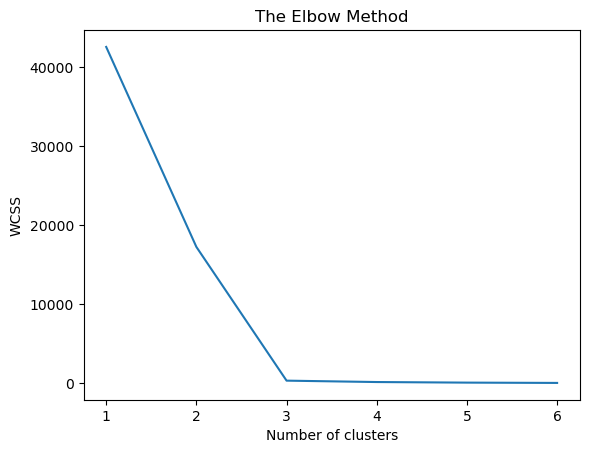

In [20]:
wcss = []
for i in range(1, 7):
    kmeans = KMeans(i)
    kmeans.fit(X)
    wcss_iter = kmeans.inertia_
    wcss.append(wcss_iter)

number_of_clusters = range(1, 7)
plt.plot(number_of_clusters, wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [21]:
# Specify number of clusters (In this case, 3 according to the elbow method)
num_clusters = 3

# Perform K Means Clustering
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(X)

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [22]:
# Get the cluster labels
labels = kmeans.labels_

# Add cluster labels to the original dataframe
df['Cluster'] = labels

In [23]:
df

,Country,Latitude,Longitude,Language,Cluster
0,USA,44.97,-103.77,English,2
1,Canada,62.40,-96.80,English,2
2,France,46.75,2.40,French,0
3,UK,54.01,-2.53,English,0
4,Germany,51.15,10.40,German,0
5,Australia,-25.45,133.11,English,1


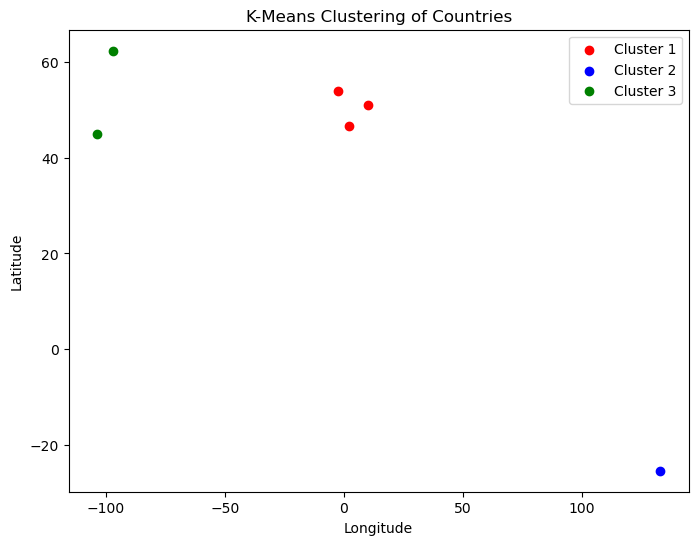

In [25]:
# Visualize the clusters
plt.figure(figsize=(8, 6))

# Assign colors to each cluster
colors = ['red', 'blue', 'green']

for i in range(num_clusters):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(cluster_data['Longitude'], cluster_data['Latitude'], 
                color=colors[i], label='Cluster {}'.format(i+1))
    

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('K-Means Clustering of Countries')
plt.legend()